Grid Search best a: 44.5 b: 1.0 MSE: 78.0869340212365
Gradient Descent a: 44.43716834983169 b: 1.165114551340942 MSE: 78.05425042124156


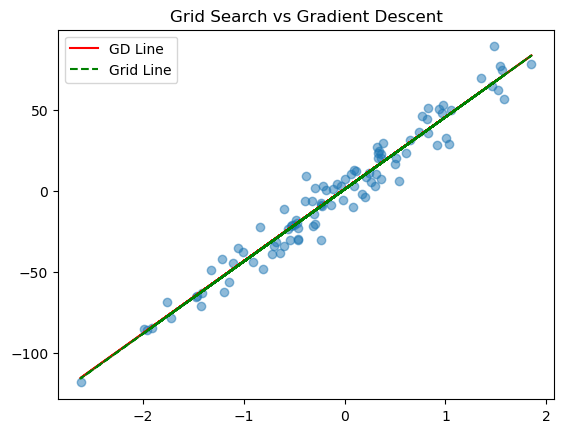

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

# Generate dataset
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
X = X.flatten()

# ---- Grid Search ----
a_vals = np.arange(-200, 201, 0.5)
b_vals = np.arange(-200, 201, 0.5)

best_a, best_b, best_mse = None, None, float("inf")
for a in a_vals:
    for b in b_vals:
        y_pred = a*X + b
        mse = mean_squared_error(y, y_pred)
        if mse < best_mse:
            best_a, best_b, best_mse = a, b, mse

print("Grid Search best a:", best_a, "b:", best_b, "MSE:", best_mse)

# ---- Gradient Descent ----
a, b = 0.0, 0.0
lr = 0.1
for _ in range(100):
    y_pred = a*X + b
    da = -2 * np.mean(X * (y - y_pred))
    db = -2 * np.mean(y - y_pred)
    a -= lr * da
    b -= lr * db

gd_mse = mean_squared_error(y, a*X + b)
print("Gradient Descent a:", a, "b:", b, "MSE:", gd_mse)

# Plot results
plt.scatter(X, y, alpha=0.5)
plt.plot(X, a*X+b, color="red", label="GD Line")
plt.plot(X, best_a*X+best_b, color="green", linestyle="--", label="Grid Line")
plt.legend()
plt.title("Grid Search vs Gradient Descent")
plt.show()
